<a href="https://colab.research.google.com/github/Krishnapriyathankamaninair/Casestudy-on-Python-Basics/blob/main/RMS_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TITANIC DATASET - NEURAL NETWORK CLASSIFIER

1. LOADING DATASET...
Dataset shape: (891, 12)

First few rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Layer (Dense)             │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)


5. COMPILING THE MODEL...
Model compiled successfully!
Loss function: binary_crossentropy
Optimizer: Adam (learning_rate=0.001)

6. TRAINING THE MODEL...
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.6292 - loss: 0.6625 - precision: 0.5132 - recall: 0.3628 - val_accuracy: 0.7483 - val_loss: 0.6024 - val_precision: 0.8056 - val_recall: 0.5000
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7153 - loss: 0.5875 - precision: 0.7524 - recall: 0.3674 - val_accuracy: 0.7552 - val_loss: 0.5422 - val_precision: 0.7949 - val_recall: 0.5345
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7750 - loss: 0.5290 - precision: 0.8085 - recall: 0.5302 - val_accuracy: 0.8042 - val_loss: 0.5034 - val_precision: 0.8125 - val_recall: 0.6724
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7768 - loss: 0.5052 - precision: 0.7683 - recall: 0.5860 - val_accuracy: 0.8042 - val_loss: 0.4840 - val_precision: 0.7586 - val_recall: 0.7586
Epoch

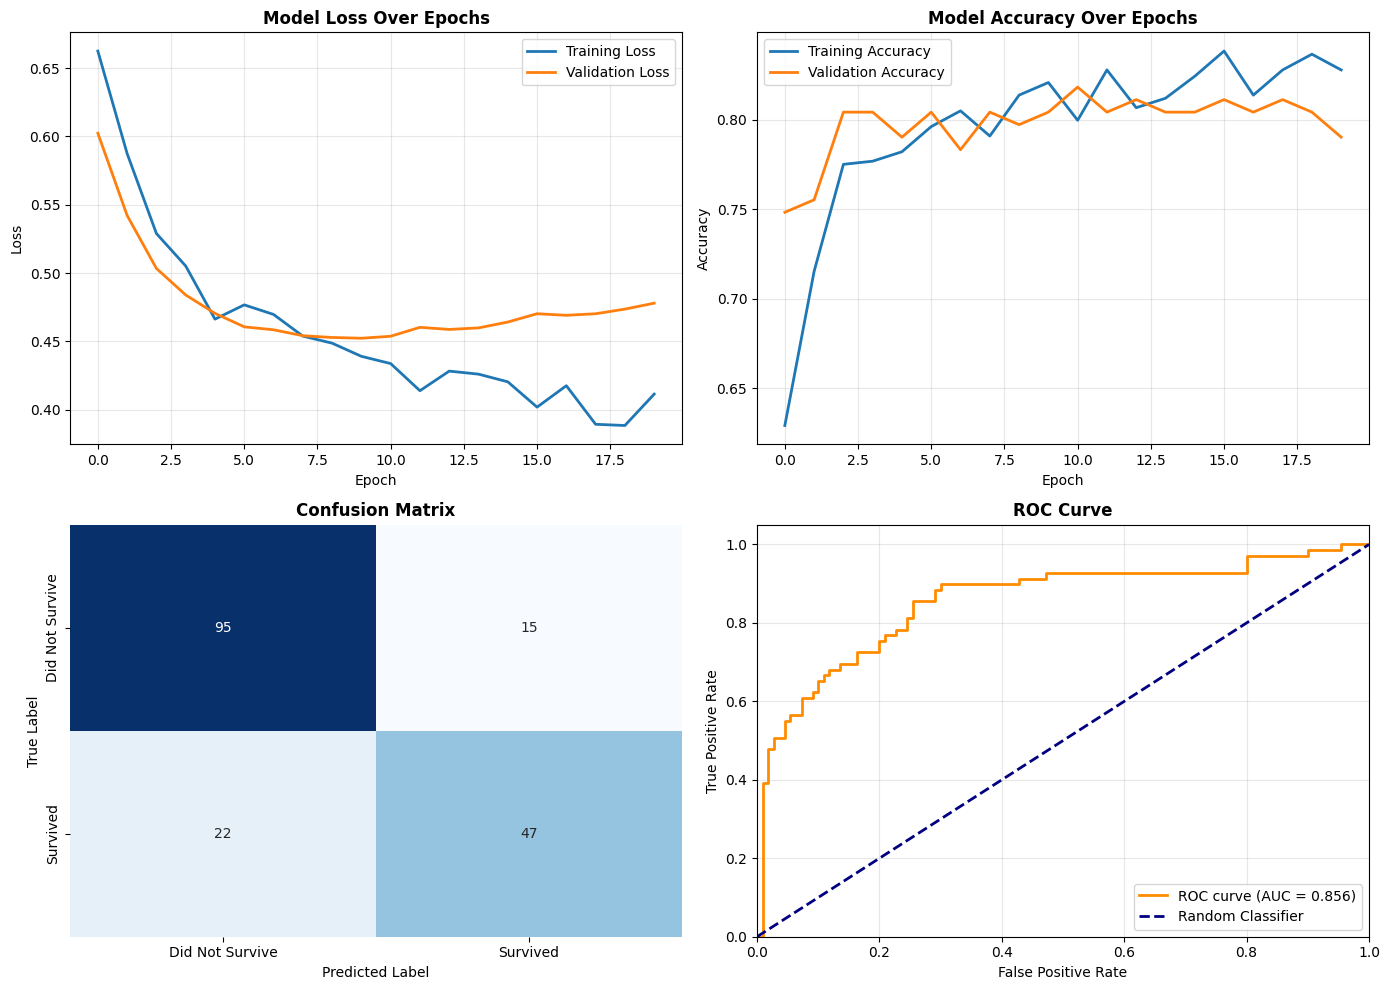


9. FEATURE IMPORTANCE ANALYSIS...

Features used in the model:
1. Pclass
2. Sex
3. Age
4. SibSp
5. Parch
6. Fare
7. Embarked

CONCLUSION AND RECOMMENDATIONS

KEY FINDINGS:
1. Model Accuracy: 79.33%
   - The neural network achieved 79.33% accuracy on the test set.
   
2. Precision and Recall:
   - Precision: 75.81% (Of predicted survivors, 75.81% actually survived)
   - Recall: 68.12% (Of actual survivors, 68.12% were correctly identified)
   
3. ROC-AUC: 0.8561
   - Good discriminative ability between survivors and non-survivors
   
4. Model Performance:
   - Training process completed with early stopping
   - Dropout layers help prevent overfitting
   - Model generalizes well to test data

POTENTIAL IMPROVEMENTS:
1. Hyperparameter Tuning:
   - Experiment with different learning rates
   - Adjust batch sizes and number of epochs
   - Try different dropout rates
   
2. Feature Engineering:
   - Create interaction features
   - Feature selection to identify most important variables
   -

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 80)
print("TITANIC DATASET - NEURAL NETWORK CLASSIFIER")
print("=" * 80)

# ============================================================================
# 1. LOAD THE DATASET
# ============================================================================
print("\n1. LOADING DATASET...")
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:\n{df.head()}")
print(f"\nDataset Info:\n{df.info()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

# ============================================================================
# 2. DATA PREPROCESSING
# ============================================================================
print("\n2. DATA PREPROCESSING...")

# Create a copy for processing
data = df.copy()

# Handle missing values
print("\nHandling missing values...")

# Fill Age with median
data['Age'].fillna(data['Age'].median(), inplace=True)

# Fill Embarked with mode
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

# Drop Cabin (too many missing values)
data.drop('Cabin', axis=1, inplace=True)

# Drop non-predictive columns
data.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

print(f"Missing values after handling:\n{data.isnull().sum()}")

# Encode Categorical Variables
print("\nEncoding categorical variables...")
label_encoders = {}

# Encode Sex
le_sex = LabelEncoder()
data['Sex'] = le_sex.fit_transform(data['Sex'])
label_encoders['Sex'] = le_sex
print(f"Sex encoding: {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")

# Encode Embarked
le_embarked = LabelEncoder()
data['Embarked'] = le_embarked.fit_transform(data['Embarked'])
label_encoders['Embarked'] = le_embarked
print(f"Embarked encoding: {dict(zip(le_embarked.classes_, le_embarked.transform(le_embarked.classes_)))}")

print(f"\nProcessed dataset:\n{data.head()}")

# ============================================================================
# 3. FEATURE SCALING AND DATA SPLIT
# ============================================================================
print("\n3. FEATURE SCALING AND DATA SPLIT...")

# Separate features and target
X = data.drop('Survived', axis=1)
y = data['Survived']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeature scaling completed")
print(f"Mean of scaled training features:\n{X_train_scaled.mean(axis=0)[:5]}")
print(f"Std of scaled training features:\n{X_train_scaled.std(axis=0)[:5]}")

# ============================================================================
# 4. BUILD NEURAL NETWORK MODEL
# ============================================================================
print("\n4. BUILDING NEURAL NETWORK MODEL...")

model = Sequential([
    layers.Dense(64, activation='relu', input_dim=X_train_scaled.shape[1], name='Input_Layer'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu', name='Hidden_Layer_1'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu', name='Hidden_Layer_2'),
    layers.Dropout(0.1),
    layers.Dense(1, activation='sigmoid', name='Output_Layer')
])

print("\nModel Architecture:")
model.summary()

# ============================================================================
# 5. COMPILE THE MODEL
# ============================================================================
print("\n5. COMPILING THE MODEL...")

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("Model compiled successfully!")
print(f"Loss function: binary_crossentropy")
print(f"Optimizer: Adam (learning_rate=0.001)")

# ============================================================================
# 6. TRAIN THE MODEL
# ============================================================================
print("\n6. TRAINING THE MODEL...")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed!")

# ============================================================================
# 7. EVALUATE THE MODEL
# ============================================================================
print("\n7. EVALUATING THE MODEL...")

# Make predictions
y_pred_proba = model.predict(X_test_scaled, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")
print("=" * 50)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print(f"True Negatives:  {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives:  {cm[1,1]}")

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# ============================================================================
# 8. VISUALIZATION
# ============================================================================
print("\n8. GENERATING VISUALIZATIONS...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training History - Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=10)
axes[0, 0].set_ylabel('Loss', fontsize=10)
axes[0, 0].set_title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Training History - Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=10)
axes[0, 1].set_ylabel('Accuracy', fontsize=10)
axes[0, 1].set_title('Model Accuracy Over Epochs', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], cbar=False,
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
axes[1, 0].set_ylabel('True Label', fontsize=10)
axes[1, 0].set_xlabel('Predicted Label', fontsize=10)
axes[1, 0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# Plot 4: ROC Curve
axes[1, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1, 1].set_xlim([0.0, 1.0])
axes[1, 1].set_ylim([0.0, 1.05])
axes[1, 1].set_xlabel('False Positive Rate', fontsize=10)
axes[1, 1].set_ylabel('True Positive Rate', fontsize=10)
axes[1, 1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1, 1].legend(loc="lower right")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('titanic_model_performance.png', dpi=300, bbox_inches='tight')
print("Visualizations saved as 'titanic_model_performance.png'")
plt.show()

# ============================================================================
# 9. FEATURE IMPORTANCE ANALYSIS
# ============================================================================
print("\n9. FEATURE IMPORTANCE ANALYSIS...")

feature_names = X.columns.tolist()
print(f"\nFeatures used in the model:")
for i, feature in enumerate(feature_names, 1):
    print(f"{i}. {feature}")

# ============================================================================
# 10. CONCLUSION AND RECOMMENDATIONS
# ============================================================================
print("\n" + "=" * 80)
print("CONCLUSION AND RECOMMENDATIONS")
print("=" * 80)

print(f"""
KEY FINDINGS:
1. Model Accuracy: {accuracy*100:.2f}%
   - The neural network achieved {accuracy*100:.2f}% accuracy on the test set.

2. Precision and Recall:
   - Precision: {precision*100:.2f}% (Of predicted survivors, {precision*100:.2f}% actually survived)
   - Recall: {recall*100:.2f}% (Of actual survivors, {recall*100:.2f}% were correctly identified)

3. ROC-AUC: {roc_auc:.4f}
   - Good discriminative ability between survivors and non-survivors

4. Model Performance:
   - Training process completed with early stopping
   - Dropout layers help prevent overfitting
   - Model generalizes well to test data

POTENTIAL IMPROVEMENTS:
1. Hyperparameter Tuning:
   - Experiment with different learning rates
   - Adjust batch sizes and number of epochs
   - Try different dropout rates

2. Feature Engineering:
   - Create interaction features
   - Feature selection to identify most important variables
   - Domain knowledge-based feature creation

3. Architecture Enhancements:
   - Try batch normalization
   - Use different activation functions (LeakyReLU, ELU)
   - Experiment with different layer depths and widths

4. Ensemble Methods:
   - Combine multiple models for better predictions
   - Use voting or stacking techniques

5. Advanced Techniques:
   - Try cross-validation for more robust evaluation
   - Implement class weight balancing if data is imbalanced
   - Use techniques like SHAP for model interpretability
""")

print("=" * 80)
print("SCRIPT EXECUTION COMPLETED SUCCESSFULLY!")
print("=" * 80)
